## GPU Configuration and Imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [2]:
import os
import tensorflow as tf
import sys
print(sys.version)
print(sys.executable)
print(sys.version_info)

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # 0,1,2,3
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
gpus = tf.config.list_physical_devices('GPU')

print(gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Error loading GPU:", e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

2025-07-14 06:54:54.655252: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-14 06:54:55.460637: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-14 06:54:55.460708: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-14 06:54:55.608084: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-14 06:54:55.901367: I tensorflow/core/platform/cpu_feature_guar

3.11.4 (main, Jul  5 2023, 13:45:01) [GCC 11.2.0]
/home/ubuntu/miniconda3/bin/python
sys.version_info(major=3, minor=11, micro=4, releaselevel='final', serial=0)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-07-14 06:55:02.295759: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-14 06:55:02.720272: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-14 06:55:02.722514: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
# Import Sionna
try:
    import sionna
except ImportError as e:
    # Install Sionna if package is not already installed
    import os
    os.system("pip install sionna")
    import sionna

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pickle

from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization, Dense, ReLU, Reshape, Conv2DTranspose, LeakyReLU, Flatten
from tensorflow.nn import relu
from tensorflow.keras.models import Sequential

from sionna.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.channel import OFDMChannel, RayleighBlockFading, GenerateOFDMChannel
from sionna.mimo import StreamManagement
from sionna.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers, ResourceGridDemapper, LMMSEInterpolator
from sionna.utils import BinarySource, ebnodb2no, insert_dims, flatten_last_dims, log10, expand_to_rank
from sionna.fec.ldpc.encoding import LDPC5GEncoder
from sionna.fec.ldpc.decoding import LDPC5GDecoder
from sionna.mapping import Mapper, Demapper, Constellation
from sionna.utils.metrics import compute_ber
from sionna.utils import sim_ber, hard_decisions

from tqdm.auto import tqdm

## Simulation Parameters <a class="anchor" id="Simulation-Parameters"></a>

In [5]:
# ## Channel configuration
carrier_frequency = 3.5e9 # Hz
delay_spread = 100e-9 # s
cdl_model = "C" # CDL model to use
speed = 10.0 # Speed for evaluation and training [m/s]
# SNR range for evaluation and training [dB]
ebno_db_min = 0.0
ebno_db_max = 20.0

############################################
## OFDM waveform configuration
subcarrier_spacing = 30e3 # Hz
fft_size = 128 # Number of subcarriers forming the resource grid, including the null-subcarrier and the guard bands
num_ofdm_symbols = 14 # Number of OFDM symbols forming the resource grid
dc_null = True # Null the DC subcarrier
num_guard_carriers = [5, 6] # Number of guard carriers on each side
pilot_pattern = "kronecker" # Pilot pattern
pilot_ofdm_symbol_indices = [2, 11] # Index of OFDM symbols carrying pilots
cyclic_prefix_length = 0 # Simulation in frequency domain. This is useless

############################################
## Modulation and coding configuration
num_bits_per_symbol = 6 # 64-QAM
coderate = 0.5 # Coderate for LDPC code
noise_dim = 100

############################################
## Neural receiver configuration
num_conv_channels = 128 # Number of convolutional channels for the convolutional layers forming the neural receiver
GAN_DIM=64

############################################
## Training configuration
num_training_iterations = 50000 # Number of training iterations
training_batch_size = 128 # Training batch size
model_weights_path_standard = "neural_receiver_weights_standard" # Location to save the neural receiver weights once training is done
model_weights_path_trained = "neural_receiver_weights_trained"

############################################
## Evaluation configuration
results_filename = "neural_receiver_results" # Location to save the results

In [6]:
stream_manager = StreamManagement(np.array([[1]]), # Receiver-transmitter association matrix
                                  1)               # One stream per transmitter

2025-07-14 06:55:04.555530: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-14 06:55:04.557457: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-14 06:55:04.559087: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

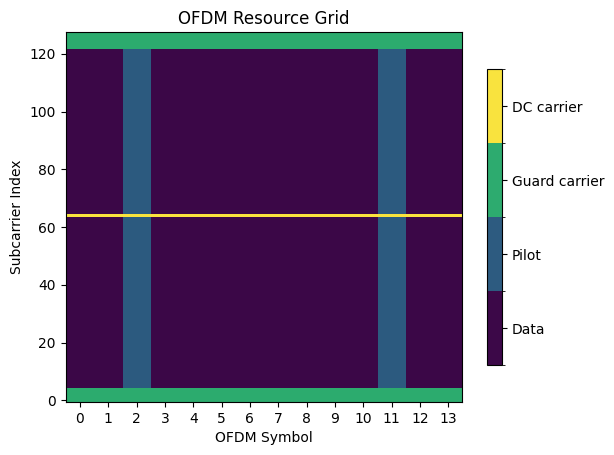

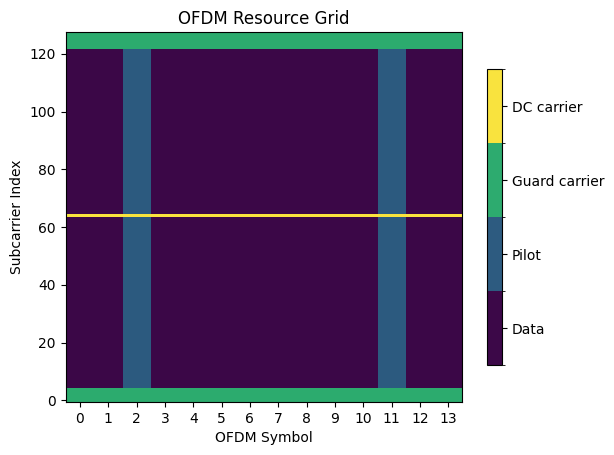

In [7]:
resource_grid = ResourceGrid(num_ofdm_symbols = num_ofdm_symbols,
                             fft_size = fft_size,
                             subcarrier_spacing = subcarrier_spacing,
                             num_tx = 1,
                             num_streams_per_tx = 1,
                             cyclic_prefix_length = cyclic_prefix_length,
                             dc_null = dc_null,
                             pilot_pattern = pilot_pattern,
                             pilot_ofdm_symbol_indices = pilot_ofdm_symbol_indices,
                             num_guard_carriers = num_guard_carriers)

resource_grid.show()

In [8]:
# Codeword length. It is calculated from the total number of databits carried by the resource grid, and the number of bits transmitted per resource element
# data symbols = 1392
n = int(resource_grid.num_data_symbols*num_bits_per_symbol)
# Number of information bits per codeword
k = int(n*coderate)
print(n)
print(k)

8352
4176


In [9]:
ut_antenna = Antenna(polarization="single",
                     polarization_type="V",
                     antenna_pattern="38.901",
                     carrier_frequency=carrier_frequency)

bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single", # dual
                        polarization_type="V", # VH
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

## Resource Grid Util

In [10]:
class ModifiedResourceGridMapper(Layer):
    def __init__(self, resource_grid, dtype=tf.complex64, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        self._resource_grid = resource_grid
        self._rg_type = self._resource_grid.build_type_grid()
        self._pilot_ind = tf.where(self._rg_type == 1)  # Indices for pilots

    def extract_pilots(self, input_rg):
        input_rg = tf.squeeze(input_rg, axis=1)
        
        pilot_grid = tf.zeros_like(input_rg)
        pilot_values = tf.gather_nd(input_rg, self._pilot_ind)
        pilot_grid = tf.tensor_scatter_nd_update(pilot_grid, self._pilot_ind, pilot_values)
        
        pilot_grid = tf.expand_dims(pilot_grid, axis=1)
        
        return pilot_grid

    def replace(self, inputs):
        # Unpack the generated and real resource grids
        generated_y_rg, real_y_rg = inputs  # (batch, 1, 2, ofdm, subcar)

        generated_y_rg = tf.squeeze(generated_y_rg, axis=1)
        real_y_rg = tf.squeeze(real_y_rg, axis=1)

        # Extract the pilots from the real resource grid
        real_pilots = tf.gather_nd(real_y_rg, self._pilot_ind)

        # Replace the pilots in the generated resource grid with the real pilots
        updated_y_rg = tf.tensor_scatter_nd_update(generated_y_rg, self._pilot_ind, real_pilots)
        updated_y_rg = tf.expand_dims(updated_y_rg, axis=1)  # Restore dimensions

        return updated_y_rg

In [11]:
@tf.function
def add_nulled_subcarriers(h_hat_active):
        """
        Add nulled subcarriers back to channel estimate.
        h_hat_active has shape (batch, 1, 1, 14, 116)
        Returns tensor with shape (batch, 1, 1, 14, 128)
        
        This method is integrated directly into the model to ensure proper gradient flow.
        """
        # Get dynamic batch size
        batch_size = tf.shape(h_hat_active)[0]
        
        # Split the 116 active subcarriers into two groups
        h_before_dc = h_hat_active[:, :, :, :, :59]   # First 59 (positions 5-63)
        h_after_dc = h_hat_active[:, :, :, :, 59:]    # Last 57 (positions 65-121)
        
        # Create zero tensors for guard bands and DC
        dtype = h_hat_active.dtype
        zeros_guard_low = tf.zeros([batch_size, 1, 1, 14, 5], dtype=dtype)    # Positions 0-4
        zeros_dc = tf.zeros([batch_size, 1, 1, 14, 1], dtype=dtype)           # Position 64 (DC)
        zeros_guard_high = tf.zeros([batch_size, 1, 1, 14, 6], dtype=dtype)   # Positions 122-127
        
        # Concatenate in the correct order: [0-4][5-63][64][65-121][122-127]
        h_hat_full = tf.concat([
            zeros_guard_low,    # Positions 0-4 (5 zeros)
            h_before_dc,        # Positions 5-63 (59 subcarriers) 
            zeros_dc,           # Position 64 (1 zero - DC)
            h_after_dc,         # Positions 65-121 (57 subcarriers)
            zeros_guard_high    # Positions 122-127 (6 zeros)
        ], axis=-1)
        
        return h_hat_full

## Neural Receiver <a class="anchor" id="Neural-Receiver"></a>

In [12]:
class ResidualBlock(Layer):
    def __init__(self, name=None, **kwargs):
        super(ResidualBlock, self).__init__(name=name, **kwargs)
    
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

class NeuralReceiver(Model):
    def __init__(self, **kwargs):
        super(NeuralReceiver, self).__init__(**kwargs)
        self.receiver = self.build_receiver()
    
    def build_receiver(self):
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None,
                                 name="neural_receiver_input_conv")
        self._output_conv = Conv2D(filters=num_bits_per_symbol,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None,
                                  name="neural_receiver_output_conv")

        inputs = tf.keras.Input(shape=(14, 128, 3))
        # Input conv
        z = self._input_conv(inputs)
        # Residual blocks
        z = ResidualBlock(name="neural_receiver_residual_block_1")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_2")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_3")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_4")(z)
        # Output conv
        z = self._output_conv(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="Neural_receiver")

    def call(self, inputs):
        y, no = inputs

        # Feeding the noise power in log10 scale helps with the performance
        no = log10(no)

        # Stacking the real and imaginary components of the different antennas along the 'channel' dimension
        y = tf.transpose(y, [0, 2, 3, 1]) # Putting antenna dimension last
        no = insert_dims(no, 3, 1)
        no = tf.tile(no, [1, y.shape[1], y.shape[2], 1])
        # z : [batch size, num ofdm symbols, num subcarriers, 2*num rx antenna + 1]
        z = tf.concat([tf.math.real(y),
                       tf.math.imag(y),
                       no], axis=-1)

        z = self.receiver(z)

        return z

In [13]:
NR = NeuralReceiver()
NR.receiver.summary()

Model: "Neural_receiver"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 14, 128, 3)]      0         
                                                                 
 neural_receiver_input_conv  (None, 14, 128, 128)      3584      
  (Conv2D)                                                       
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_1 (ResidualBlock)                                          
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_2 (ResidualBlock)                                          
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_3 (ResidualBlock)                            

## Conv2D GAN

In [14]:
class GANGenerator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANGenerator, self).__init__(**kwargs)
        self.generator = self.build_generator()

    def build_generator(self):
        """Builds the generator model."""
        x_real_input = tf.keras.layers.Input(shape=(14,128,2))  # (batch,14,128,2)
        noise_input = tf.keras.layers.Input(shape=(14,128,noise_dim)) 
        c_input = tf.keras.layers.Input(shape=(14,128,2))  # (batch,14,128,2) or (batch,14,128,4)
        
        x = tf.keras.layers.Concatenate()([x_real_input, noise_input, c_input])

        x = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=512, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=2, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        
        return  tf.keras.Model(inputs=[x_real_input, noise_input, c_input], outputs=x, name="GANChannel_Generator")
    
    def call(self, z, x, extra_condition):
        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0,2,3,1])
        x_real, x_imag = tf.math.real(x), tf.math.imag(x) # [batch,14,128,ant]
        x_flat = tf.concat([x_real, x_imag], axis=-1) #  [batch,14,128,2*ant]

        c = tf.squeeze(extra_condition, axis=1)
        c = tf.transpose(c, [0,2,3,1])
        c_real, c_imag = tf.math.real(c), tf.math.imag(c) # [batch,14,128,ant]
        c_flat = tf.concat([c_real, c_imag], axis=-1) #  [batch,14,128,2*ant]
        
        y = self.generator([x_flat, z, c_flat]) # [batch,14,128,2]
        
        y = tf.reshape(y, (batch_size, 14, 128, 2, 1))

        y_r = y[:, :, :, 0, :]  # (batch, 14, 128, rx_ant)
        y_i = y[:, :, :, 1, :]  # (batch, 14, 128, rx_ant) 
        y_r = tf.transpose(y_r, [0, 3, 1, 2])  # (batch, rx_ant, 14, 128)
        y_i = tf.transpose(y_i, [0, 3, 1, 2])  # (batch, rx_ant, 14, 128)
        y_complex = tf.complex(y_r, y_i)
        
        y_complex = tf.expand_dims(y_complex, axis=1)
        
        return y_complex

In [15]:
gan_generator = GANGenerator()
gan_generator.generator.summary()

Model: "GANChannel_Generator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 14, 128, 100)]       0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 14, 128, 104)         0         ['input_2[0][0]',             
                                                                     'input_3[0

In [16]:
class GANDiscriminator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANDiscriminator, self).__init__(**kwargs)
        self.discriminator = self.build_discriminator()
    
    def build_discriminator(self):
        """Builds the discriminator model."""
        y_rg = tf.keras.layers.Input(shape=(14,128,6)) # 14,128,6 or 14,128,8

        y = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same')(y_rg)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)
        y = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same')(y)
        # y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)
        y = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same')(y)
        # y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)

        y = tf.keras.layers.Flatten()(y)
        # FC = tf.nn.relu(tf.keras.layers.Dense(100, activation=None)(FC))
        D_logit = tf.keras.layers.Dense(1, activation='linear')(y) # sigmoid
        # D_prob = tf.nn.sigmoid(conv4)
        
        return tf.keras.Model(inputs=y_rg, outputs=D_logit, name="GANChannel_Discriminator")
    
    def call(self, y, x, extra_condition):
        y = tf.squeeze(y, axis=1)
        y = tf.transpose(y, [0,2,3,1])
        y_real, y_imag = tf.math.real(y), tf.math.imag(y) # [batch,14,128,ant]
        y_cat = tf.concat([y_real, y_imag], axis=-1) # [batch,14,128,2*ant]

        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0,2,3,1])
        x_real, x_imag = tf.math.real(x), tf.math.imag(x) # [batch,14,128,ant]
        x_cat = tf.concat([x_real, x_imag], axis=-1) # [batch,14,128,2*ant]

        c = tf.squeeze(extra_condition, axis=1)
        c = tf.transpose(c, [0,2,3,1])
        c_real, c_imag = tf.math.real(c), tf.math.imag(c) # [batch,14,128,ant]
        c_cat = tf.concat([c_real, c_imag], axis=-1) #  [batch,14,128,2*ant]
        
        cat = tf.concat([y_cat, x_cat, c_cat], axis=-1) # [batch,14,128,c]

        y_logit = self.discriminator(cat)
        
        return y_logit

In [17]:
gan_discriminator = GANDiscriminator()
gan_discriminator.discriminator.summary()

Model: "GANChannel_Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 14, 128, 6)]      0         
                                                                 
 conv2d_12 (Conv2D)          (None, 14, 128, 64)       3520      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 14, 128, 64)       0         
                                                                 
 conv2d_13 (Conv2D)          (None, 14, 128, 128)      73856     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 14, 128, 128)      0         
                                                                 
 conv2d_14 (Conv2D)          (None, 14, 128, 256)      295168    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 14, 12

## End-to-end System <a class="anchor" id="End-to-end-System"></a>

In [18]:
## Transmitter
binary_source = BinarySource()
# mapper = Mapper("qam", num_bits_per_symbol)
# rg_mapper = ResourceGridMapper(resource_grid)

constellation = Constellation("qam", num_bits_per_symbol, trainable=True)
mapper = Mapper(constellation=constellation)
rg_mapper = ResourceGridMapper(resource_grid)

## Channel
cdl = CDL(cdl_model, delay_spread, carrier_frequency,
          ut_antenna, bs_array, "uplink", min_speed=speed)
channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

## Receiver
neural_receiver = NeuralReceiver()
rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements

# resource grid helper
rg_util = ModifiedResourceGridMapper(resource_grid)

### Test Definition

In [29]:
batch_size = 128
ebno_db = tf.fill([batch_size], 5.0)
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
z = tf.random.normal(shape=(batch_size, 1, 14, 128))

## Transmitter
c = binary_source([batch_size, 1, 1, n])
print("c shape: ", c.shape)

# Map bits to QAM symbols
x = mapper(c)
print("x shape: ", x.shape)

# Map the QAM symbols to a resource grid
x_rg = rg_mapper(x)
print("x_rg shape: ", x_rg.shape)

######################################
## Channel
# A batch of new channel realizations is sampled and applied at every inference
no_ = expand_to_rank(no, tf.rank(x_rg))
y,_ = channel([x_rg, no_])
print("y shape: ", y.shape)
y_p = rg_util.extract_pilots(y)
print("y_p shape: ", y_p.shape)

######################################
## Receiver
# The neural receover computes LLRs from the frequency domain received symbols and N0
y = tf.squeeze(y, axis=1)
llr = neural_receiver([y, no])
print("llr shape: ", llr.shape)
# Reshape the input to fit what the resource grid demapper is expected
llr = insert_dims(llr, 2, 1)
# Extract data-carrying resource elements. The other LLRs are discarded
llr = rg_demapper(llr) # 1392 from 1792 (14*128)
print("LLRs before reshape: ", llr.shape)
llr = tf.reshape(llr, [batch_size, 1, 1, n])
print("Post RG-demapper LLRs: ", llr.shape)

c shape:  (128, 1, 1, 8352)
x shape:  (128, 1, 1, 1392)
x_rg shape:  (128, 1, 1, 14, 128)
y shape:  (128, 1, 1, 14, 128)
y_p shape:  (128, 1, 1, 14, 128)
llr shape:  (128, 14, 128, 6)
LLRs before reshape:  (128, 1, 1, 1392, 6)
Post RG-demapper LLRs:  (128, 1, 1, 8352)


In [20]:
bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
bce = tf.reduce_mean(bce)
rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
print(f"Rate: {rate:.2E} bit")

Rate: -3.26E-01 bit


## End-to-end System as a Keras Model <a class="anchor" id="End-to-end-System-as-a-Keras-Model"></a>

In [ ]:
FREQ_COV_MAT = np.load('freq_cov_mat.npy')
TIME_COV_MAT = np.load('time_cov_mat.npy')
SPACE_COV_MAT = np.load('space_cov_mat.npy')
freq_cov_mat = tf.constant(FREQ_COV_MAT, tf.complex64)
time_cov_mat = tf.constant(TIME_COV_MAT, tf.complex64)

active_mask = tf.concat([
   tf.zeros(num_guard_carriers[0], dtype=tf.bool),
   tf.ones(fft_size - num_guard_carriers[0] - num_guard_carriers[1] - 1, dtype=tf.bool),
   tf.zeros(1, dtype=tf.bool),  # DC
   tf.ones(0, dtype=tf.bool) if num_guard_carriers[1] == 0 else tf.zeros(num_guard_carriers[1], dtype=tf.bool)
], axis=0)

active_indices = tf.where(active_mask)[:, 0]
freq_cov_mat = tf.gather(tf.gather(freq_cov_mat, active_indices, axis=0), active_indices, axis=1)
print(freq_cov_mat.shape, time_cov_mat.shape)  # Should be (116, 116), (14, 14)
# Use the processed matrix
lmmse_int_freq_first = LMMSEInterpolator(resource_grid.pilot_pattern, 
                                         time_cov_mat, 
                                         freq_cov_mat, 
                                         order='t-f')
channel_estimator = LSChannelEstimator(resource_grid, interpolator=lmmse_int_freq_first)

(116, 116) (14, 14)


In [ ]:
class E2ESystem(Model):
    def __init__(self, training=False):
        super().__init__()
        self._training = training
        self.x_rg = None
        self.y_gen = None
        self.y_real = None
        self.h_freq = None
        self.prior_constellation = None
        self.post_constellation = None
        # self.ls_estimator = LSChannelEstimator(resource_grid, interpolation_type="nn")

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training:
            self._encoder = LDPC5GEncoder(k, n)
            
        # Trainable constellation
        constellation = Constellation("qam", num_bits_per_symbol, trainable=True)
        self.constellation = constellation
        self._mapper = Mapper(constellation=constellation)
        self._rg_mapper = ResourceGridMapper(resource_grid)         

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._real_channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

        self._gan_channel = GANGenerator()

        ######################################
        ## Receiver
        self._neural_receiver = NeuralReceiver()
        self._rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements
            
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)
    
    @tf.function
    def call(self, batch_size, ebno_db, use_gan_channel=False):
        
        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)

        ######################################
        ## Transmitter
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        
        # Outer coding is only performed if not training
        if self._training:
            c = self._binary_source([batch_size, 1, 1, n]) # u=4176*2
        else:
            b = self._binary_source([batch_size, 1, 1, k]) # k=4176
            c = self._encoder(b) # u=n=4176*2
        
        # c = self._binary_source([batch_size, 1, 1, n]) # for uncoded simulation
        
        # Modulation
        self.prior_constellation = c
        x = self._mapper(c)
        self.post_constellation = x
        
        x_rg = self._rg_mapper(x)

        self.x_rg = x_rg

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._real_channel([x_rg, no_])

        self.y_real = y

        ### ----------------- GAN channel
        if use_gan_channel: 
            z = tf.random.normal([batch_size, 14, 128, noise_dim])
            
            # channel estimation
            h_hat, _ = channel_estimator([self.y_real, no_]) # (128, 1, 1, 1, 1, 14, 128)
            h_hat = h_hat[:,:,:,0,0,:,:] # (128, 1, 1, 14, 128)

            h_hat = add_nulled_subcarriers(h_hat)
            
            # extract pilots
            y_p = rg_util.extract_pilots(self.y_real) 
            x_p = rg_util.extract_pilots(x_rg)
            pilots = tf.concat([y_p, x_p], axis=2) # (batch, 1, 2+2, 14, 128)
            h_freq = h[:,:,:,0,0,:,:]
        
            condition = self.y_real # y_real, h, h_hat, pilots
            
            y = self._gan_channel(z, x_rg, condition)
            
            self.h_freq = h
            self.y_gen = y
            
        ######################################
        ## Receiver    
        # The neural receover computes LLRs from the frequency domain received symbols and N0
        y = tf.squeeze(y, axis=1)
        llr = self._neural_receiver([y, no])
        llr = insert_dims(llr, 2, 1) # Reshape the input to fit what the resource grid demapper is expected
        llr = self._rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
        llr = tf.reshape(llr, [batch_size, 1, 1, n]) # Reshape the LLRs to fit what the outer decoder is expected

        # Outer coding is not needed if the information rate is returned
        if self._training:
            # Compute and return BMD rate (in bit), which is known to be an achievable
            # information rate for BICM systems. Training aims at maximizing the BMD rate
            bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            if use_gan_channel:
                return rate, self.x_rg, self.y_gen, self.y_real, self.h_freq, no_
            else:
                return rate
        else:
            # Outer decoding
            b_hat = self._decoder(llr)
            return b,b_hat # k=4176
            # probabilities = tf.math.sigmoid(llr)
            # b_hat = tf.cast(probabilities > 0.5, dtype=tf.float32) # 0.5-1 is False=bit 0; 0-0.5 is True=bit 1 
            # return c,b_hat # Ground truth and reconstructed information bits returned for BER/BLER computation

## PSD

In [39]:
def compute_psd_line(y):
    y = tf.squeeze(y, axis=[1,2])
    fft_result = tf.signal.fft(y)  # Shape: [batch, 14, 128]
    power_db = 20 * tf.math.log(tf.abs(fft_result) + 1e-10) / tf.math.log(10.0)  # Convert to dB
    power_db_shifted = tf.signal.fftshift(power_db, axes=[-1])  # Shape: [batch, 14, 128]
    return tf.reduce_mean(power_db_shifted, axis=1)  # Shape: [batch, 128]

def plot_psd_line(psd_real, psd_fake):
    # Convert to NumPy and average over batch
    psd_real_np = psd_real.numpy().mean(axis=0)  # Shape: [128]
    psd_fake_np = psd_fake.numpy().mean(axis=0)  # Shape: [128]
    
    # Frequency axis (normalized subcarriers)
    freq_axis = np.linspace(-0.5, 0.5, psd_real_np.shape[-1])  # Normalized frequencies
    # Plot
    plt.figure(figsize=(8, 2))
    plt.plot(freq_axis, psd_real_np, label="Real PSD", linewidth=2)
    plt.plot(freq_axis, psd_fake_np, label="Generated PSD", linewidth=2)
    plt.xlabel("Normalized Frequency")
    plt.ylabel("PSD (dB)")
    plt.title("Power Spectral Density of OFDM Signal")
    plt.legend()
    plt.grid()
    plt.show()

def compute_psd(y):
    y = tf.squeeze(y, axis=[1,2])
    # fft_result = tf.signal.fft2d(y)
    # power = tf.abs(fft_result)**2
    fft_result = tf.signal.fft(y) 
    power_db = 20 * tf.math.log(tf.abs(fft_result) + 1e-10) / tf.math.log(10.0)  # Convert to dB
    power = tf.signal.fftshift(power_db, axes=[-1])  # Shape: [batch, 14, 128]
    # Average over the batch dimension
    psd = tf.reduce_mean(power, axis=0)  # Shape: [14, 128]
    
    return psd

def plot_psd(psd_real, psd_generated):
    vmin = min(np.min(psd_real.numpy()), np.min(psd_generated.numpy()))
    vmax = max(np.max(psd_real.numpy()), np.max(psd_generated.numpy()))

    plt.figure(figsize=(12, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(psd_real.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Real PSD')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(psd_generated.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Generated PSD')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()

In [40]:
def plot_phase_amp_distribution(real_y, generated_y):
    phase_real = tf.math.angle(real_y).numpy().flatten()
    phase_fake = tf.math.angle(generated_y).numpy().flatten()

    plt.figure(figsize=(7, 3))
    plt.subplot(1, 2, 1)
    bins = np.linspace(-np.pi, np.pi, 50)
    plt.hist(phase_real, bins=bins, alpha=0.5, label="Real", density=True)
    plt.hist(phase_fake, bins=bins, alpha=0.5, label="Generated", density=True)
    plt.xlabel("Phase (radians)")
    plt.ylabel("Density")
    plt.title("Phase Distribution")
    plt.legend()
    plt.grid()
    
    real_amplitude = np.abs(real_y).flatten()
    gen_amplitude = np.abs(generated_y).flatten()
    
    plt.subplot(1, 2, 2)  
    all_data = np.concatenate((real_amplitude, gen_amplitude))
    bins = np.linspace(np.min(all_data), np.max(all_data), 50)  # Define bins properly
    plt.hist(real_amplitude, bins=bins, density=True, alpha=0.5, color='blue', label='Real')
    plt.hist(gen_amplitude, bins=bins, density=True, alpha=0.5, color='red', label='Generated')
    plt.xlabel("Amplitude")
    plt.ylabel("Density")
    plt.title("Amplitude Distribution")
    plt.legend()
    plt.grid()
    
    plt.tight_layout()
    plt.show()

## Training Parameters

In [57]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionnary storing the evaluation results
BLER = {}
BER = {}

In [58]:
def gradient_penalty(disc, y_real, y_fake, x_real, condition):
    lamb = 10
    batchlen = tf.shape(y_real)[0]  # batch size of y_real or y_fake
    
    epsilon = tf.random.uniform([batchlen, 1,1,1,1], minval=0, maxval=1, dtype=tf.float32) # interpolation factor (0-1)
    # epsilon = epsilon[:, None, None, None, None]
    
    # Interpolating between real and fake post-fft y
    y_real = tf.cast(y_real, tf.float32)
    y_fake = tf.cast(y_fake, tf.float32)
    interpolated = epsilon * y_real + (1 - epsilon) * y_fake
    
    # Gradient calculation
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        D_logit_pred = disc(interpolated, x_real, condition)

    grads = gp_tape.gradient(D_logit_pred, interpolated)

    # num_elements = tf.reduce_prod(tf.shape(grads)[1:])
    grad_norms = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3,4])) # / tf.cast(num_elements, tf.float32) )
    # print(tf.reduce_mean(grads), tf.reduce_mean(grad_norms))
    
    gp = lamb * tf.reduce_mean(tf.square(grad_norms - 1))
    # gp = lamb * tf.reduce_mean(tf.clip_by_value(grad_norms - 1., 0., np.infty)**2)
    
    return gp, tf.reduce_mean(grad_norms)

In [59]:
# -------- only rerun this cell if need to reset training
model = E2ESystem(training=True)
eval_model = E2ESystem(training=False)

WG = GANGenerator()
WD = GANDiscriminator()

list_D = []
list_G = []

# Parameters
lr = 0.0001
epoch = 3000
snr_db = 10.0  # in dB

optimizer_G = tf.keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.9)
optimizer_D = tf.keras.optimizers.Adam(lr, beta_1=0.5, beta_2=0.9)

# # offset
# model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=True)
# with open('gan_weights/gan_weights_G_1000.pkl', 'rb') as f:
#     g_weights = pickle.load(f)
# WG.set_weights(g_weights)
# with open('gan_weights/gan_weights_D_1000.pkl', 'rb') as f:
#     d_weights = pickle.load(f)
# WD.set_weights(d_weights)

In [60]:
@tf.function
def WGAN_train_step(y_real, x_rg, condition):
    z = tf.random.normal([batch_size, 14, 128, noise_dim])
    y_fake = WG(z, x_rg, condition)

    # Train Discriminator
    for j in range(1): # DISCRIMINATOR_TRAININGS_PER_GENERATOR_TRAINING adjust accordingly
        with tf.GradientTape() as tape_D:
            d_real = WD(y_real, x_rg, condition)
            d_fake = WD(y_fake, x_rg, condition)

            gp, grad_norm = gradient_penalty(WD, y_real, y_fake, x_rg, condition)
            loss_D = tf.reduce_mean(d_fake) - tf.reduce_mean(d_real) + gp
            
        grads_D = tape_D.gradient(loss_D, WD.trainable_variables)
        optimizer_D.apply_gradients(zip(grads_D, WD.trainable_variables))

    # Train Generator
    for k in range(1): # adjust accordingly
        with tf.GradientTape() as tape_G:
            y_fake = WG(z, x_rg, condition)
            d_fake = WD(y_fake, x_rg, condition)
            
            loss_G = -tf.reduce_mean(d_fake)
            
        grads_G = tape_G.gradient(loss_G, WG.trainable_variables)
        optimizer_G.apply_gradients(zip(grads_G, WG.trainable_variables))
    
    return d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake

In [61]:
optimizer = tf.keras.optimizers.legacy.Adam()

@tf.function
def E2E_train__tx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, (Constellation, Mapper)):
            layer.trainable = True  
        else:
            layer.trainable = False  
    tx_weights = model.trainable_weights
    # for w in tx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate, _, y_gen, y_real, h_freq, _ = model(training_batch_size, ebno_db, use_gan_channel=True)
        loss = -rate 
    
    grads_tx = tape.gradient(loss, tx_weights)
    optimizer.apply_gradients(zip(grads_tx, tx_weights))
    
    return loss, y_gen, y_real

@tf.function
def E2E_train__rx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, NeuralReceiver):
            layer.trainable = True 
        else:
            layer.trainable = False
    rx_weights = model.trainable_weights
    # for w in rx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(training_batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads_rx = tape.gradient(loss, rx_weights)
    optimizer.apply_gradients(zip(grads_rx, rx_weights))

    return loss

## Training the WGAN

In [ ]:
# May need to manually run set update ratio for D and G
# For future work, a scheduler may work better

for i in tqdm(range(offset, epoch+1)):    
    # Sampling a batch of SNRs
    # ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    ebno_db = tf.constant(10.0, tf.float32)
    
    _, x_rg, _, y_real, h_freq, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, None) 
    
    gan_weights_G = WG.get_weights()
    gan_weights_D = WD.get_weights()

    # -----------------------------------------------------------------------     
    if i % 10 == 0: 
        list_D.append(loss_D)
        list_G.append(loss_G)
        psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
        psd_generated = compute_psd(y_fake)
        mse_psd = tf.reduce_mean((psd_real - psd_generated)**2)

        print(f"Epoch [{i}/{epoch}] w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, mse(PSD): {mse_psd.numpy():.4f}") 
    
    if i % 100 == 0:    
        print(np.mean(y_fake), np.mean(y_real))
        
        psd_real_line = compute_psd_line(y_real)
        psd_generated_line = compute_psd_line(y_fake)
        plot_psd_line(psd_real_line, psd_generated_line)
        
        plot_phase_amp_distribution(y_real, y_fake)

        plot_psd(psd_real, psd_generated)

    if i % 1000 == 0: 
        # save GAN weights
        with open(f'gan_weights/gan_weights_G_{i}.pkl', 'wb') as f2:
            pickle.dump(gan_weights_G, f2)
        with open(f'gan_weights/gan_weights_D_{i}.pkl', 'wb') as f3:
                pickle.dump(gan_weights_D, f3)

In [ ]:
G_L = np.asarray(list_G)
D_L = np.asarray(list_D)

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(G_L, label='generator')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(D_L, label = 'discriminator')
plt.tight_layout()
plt.legend()
plt.show()

## Training Nerual Transmitter and Receiver <a class="anchor" id="Training-the-Neural-Receiver"></a>

In [ ]:
# model(1, tf.constant(10.0, tf.float32), use_gan_channel=True)
# model.summary()
eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
# eval_model.summary()
e_weights = eval_model.trainable_weights
for w in e_weights:
    print(f"Layer: {w.name}, Shape: {w.shape}")

In [ ]:
# for layer in model.layers:
#     if isinstance(layer, NeuralReceiver):
#         layer.trainable = True  # Ensure the receiver is trainable
#     else:
#         layer.trainable = False  # Freeze all other layers
for layer in model.layers:
        layer.trainable = True
weights = model.trainable_weights
for w in weights:
    print(f"Layer: {w.name}, Shape: {w.shape}")

In [26]:
offset = 0
model = E2ESystem(training=True)
eval_model = E2ESystem(training=False)
model(training_batch_size, ebno_db, use_gan_channel=False)
# with open('weights_trained/model_weights_50000.pkl', 'rb') as f:
#     weights = pickle.load(f)
# model.set_weights(weights)  
with open('ofdm_wgan_weights_G_conv2d_3000.pkl', 'rb') as f:
    gan_weights_G = pickle.load(f)
model._gan_channel.set_weights(gan_weights_G)

# -----------------------------------------------------------------
for i in tqdm(range(offset, num_training_iterations+1)): 
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    loss_tx, y_gen, y_real = E2E_train__tx_step(ebno_db)

    if i % 1000 == 0:
        with open(f'y_output/tx_generated_y_{i}.txt', 'w') as f1:
            np.savetxt(f1, y_gen.numpy().reshape(-1), fmt='%.6f')
        with open(f'y_output/tx_real_y_{i}.txt', 'w') as f2:
            np.savetxt(f2, y_real.numpy().reshape(-1), fmt='%.6f')
    
    loss_rx = E2E_train__rx_step(ebno_db)
     
    for layer in model.layers:
        layer.trainable = True
    weights = model.get_weights()
        
    if i % 1000 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss_tx: {loss_tx.numpy():.4f}, Loss_rx: {loss_rx.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        # validation at 3.5dB
        ber, bler = sim_ber(eval_model, [3.5], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 1000 == 0:
        with open(f'weights_trained/model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open(model_weights_path_trained, 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/50001 [00:00<?, ?it/s]

Iteration 0/50000, Eb/No: 3.3284, Loss_tx: 0.3922, Loss_rx: 0.3900
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      3.5 | 5.0036e-01 | 1.0000e+00 |      267457 |      534528 |          128 |         128 |         0.4 |reached target block errors
Iteration 1000/50000, Eb/No: 6.0362, Loss_tx: -0.3808, Loss_rx: -0.4006
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      3.5 | 2.7107e-01 | 1.0000e+00 |      144894 |      534528 |          128 |         128 |         0.3 |reached target block errors
Iteration 2000/50000, Eb/No: 8.4584, Loss_tx: -0.4438, Loss_rx: -0.5797
EbNo [d

## Joint training

In [62]:
# pre-trained until converge (or 4000 iterations)
model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=True)
with open('siso_ofdm_wgan_weights_G_pilots_4000.pkl', 'rb') as f:
    g_weights = pickle.load(f)
WG.set_weights(g_weights)
with open('siso_ofdm_wgan_weights_D_pilots_4000.pkl', 'rb') as f:
    d_weights = pickle.load(f)
WD.set_weights(d_weights)

In [ ]:
offset = 0
for i in tqdm(range(offset, num_training_iterations+1)):  
    
    train_GAN = True if (i % 10 == 0) else False # Train GAN every 10 iterations (50000/10=5000 times)
    if train_GAN:
        # Sampling a batch of SNRs
        ebno_db = tf.constant(10.0, tf.float32)
        
        _, x_rg, _, y_real, h_freq, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    
        # channel estimation
        # h_hat, _ = channel_estimator([y_real, sigma2]) # (128, 1, 1, 1, 1, 14, 128)
        # h_hat = h_hat[:,:,:,0,0,:,:] # (128, 1, 1, 14, 128)

        # h_hat = add_nulled_subcarriers(h_hat)

        # extract pilots
        y_p = rg_util.extract_pilots(y_real) 
        x_p = rg_util.extract_pilots(x_rg)
        pilots = tf.concat([y_p, x_p], axis=2) # (batch, 1, 2+2, 14, 128)
        # h_real = h_freq[:,:,:,0,0,:,:] # (128, 1, 1, 14, 128)
    
        # condition
        condition = pilots # y_real, h_freq, h_hat, pilots
        
        d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, condition) 
        
        gan_weights_G = WG.get_weights()
        gan_weights_D = WD.get_weights()
    
        # -----------------------------------------------------------------------     
        if i % 100 == 0: 
            list_D.append(loss_D)
            list_G.append(loss_G)
            psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
            psd_generated = compute_psd(y_fake)
            mse_psd = tf.reduce_mean((psd_real - psd_generated)**2)
    
            print(f"Epoch [{i//10}/{num_training_iterations//10}] w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, mse(PSD): {mse_psd.numpy():.4f}") 
    
        if i % 1000 == 0: 
            print(np.mean(y_fake), np.mean(y_real))
            
            psd_real_line = compute_psd_line(y_real)
            psd_generated_line = compute_psd_line(y_fake)
            plot_psd_line(psd_real_line, psd_generated_line)
            
            plot_phase_amp_distribution(y_real, y_fake)
    
            plot_psd(psd_real, psd_generated)
    
        if i % 5000 == 0: 
            with open(f'y_output/pilots_train_generated_y_{i}.txt', 'w') as f:
                np.savetxt(f, y_fake.numpy().reshape(-1), fmt='%.6f')
            with open(f'y_output/pilots_train_real_y_{i}.txt', 'w') as f:
                np.savetxt(f, y_real.numpy().reshape(-1), fmt='%.6f')
    
            # save GAN weights
            with open(f'gan_weights/pilots_gan_weights_G_{i}.pkl', 'wb') as f2:
                pickle.dump(gan_weights_G, f2)
            with open(f'gan_weights/pilots_gan_weights_D_{i}.pkl', 'wb') as f3:
                    pickle.dump(gan_weights_D, f3)

            np.savez('gan_losses_pilots.npz', generator=np.asarray(list_G), discriminator=np.asarray(list_D))

    # -----------------------------------------------------------------------
    gan_weights_G = WG.get_weights()
    model._gan_channel.set_weights(gan_weights_G)
    # -----------------------------------------------------------------------
    
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    loss_tx, y_gen, y_real = E2E_train__tx_step(ebno_db)

    if i % 1000 == 0:
        with open(f'y_output/pilots_tx_generated_y_{i}.txt', 'w') as f1:
            np.savetxt(f1, y_gen.numpy().reshape(-1), fmt='%.6f')
        with open(f'y_output/pilots_tx_real_y_{i}.txt', 'w') as f2:
            np.savetxt(f2, y_real.numpy().reshape(-1), fmt='%.6f')
    
    loss_rx = E2E_train__rx_step(ebno_db)
     
    for layer in model.layers:
        layer.trainable = True
    weights = model.get_weights()
        
    if i % 100 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss_tx: {loss_tx.numpy():.4f}, Loss_rx: {loss_rx.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        # validation at 3.5dB
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 5000 == 0:
        with open(f'weights_trained/pilots_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open(model_weights_path_trained, 'wb') as f:
    pickle.dump(weights, f)

In [ ]:
G_L = np.asarray(list_G)
D_L = np.asarray(list_D)
plt.figure()
plt.plot(G_L, label='generator')
plt.plot(D_L, label='discriminator')
plt.legend()
plt.savefig('gan_loss_plot_pilots.png', dpi=300)  # Save the plot as an image
plt.text(0.02, 0.98, '(e)', transform=plt.gca().transAxes, 
         fontsize=14, fontweight='bold', va='top', ha='left')
plt.show()

np.savez('gan_losses_pilots.npz', generator=G_L, discriminator=D_L)

In [ ]:
# Load the saved losses
data = np.load('gan_losses_pilots.npz')
# G_L = data['generator'][:5000]  # Limit to first 4000 data points
# D_L = data['discriminator'][:5000]  # Limit to first 4000 data points

iterations = np.arange(len(G_L)) * 100

plt.figure()
plt.plot(iterations, G_L, label='generator')
plt.plot(iterations, D_L, label='discriminator')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.text(0.02, 0.98, '(a)', transform=plt.gca().transAxes, 
         fontsize=14, fontweight='bold', va='top', ha='left')
plt.savefig('gan_loss_plot_pilots.png', dpi=300)  # Save the plot as an image
plt.show()

## Learned Constellation <a class="anchor" id="Constellation"></a>

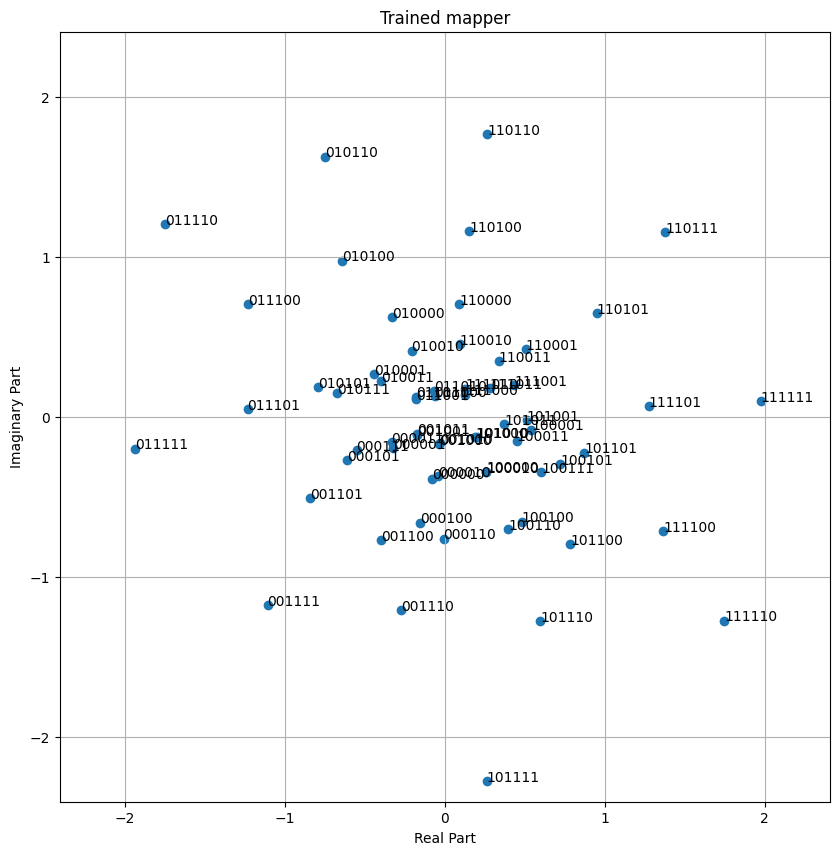

In [28]:
# Utility function to load and set weights of a mode
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32))
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
model = E2ESystem(training=True)
load_weights(model, "weights_trained/receivedY_model_weights_50000.pkl")

# fig = model.constellation.show()
constellation = model.constellation
figsize=(10,10)
maxval = np.max(np.abs(constellation.points))*1.05
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation.points), np.imag(constellation.points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained mapper")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
for j, p in enumerate(constellation.points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )

In [ ]:
# current_config = {
#     'weight_path': 'weights_trained/pilots_model_weights_50000.pkl',
#     'condition_label': r'$\mathbf{x}_p$ and $\mathbf{y}_p$', 
#     'subplot_index': 0,  # 0, 1, or 2
#     'subplot_label': '(a)'  # '(a)', '(b)', or '(c)'
# }

# current_config = {
#     'weight_path': 'weights_trained/hhat_model_weights_50000.pkl',
#     'condition_label': r'$\hat{\mathbf{h}}$', 
#     'subplot_index': 1,
#     'subplot_label': '(b)'
# }

current_config = {
    'weight_path': 'weights_trained/receivedY_model_weights_50000.pkl',
    'condition_label': r'$\mathbf{Y}_{rg}$', 
    'subplot_index': 2,
    'subplot_label': '(c)'
}

# File to store the figure state
data_state_file = 'constellation_data_state.pkl'

def extract_constellation_data(weight_path):
    """Extract constellation data without plotting"""
    model = E2ESystem(training=True)
    load_weights(model, weight_path)
    constellation = model.constellation
    return constellation.points

# Load existing data or create new storage
if os.path.exists(data_state_file):
    with open(data_state_file, 'rb') as f:
        plot_data = pickle.load(f)
    print(f"Loaded existing data. Completed: {list(plot_data.keys())}")
else:
    plot_data = {}
    print("Created new data storage")

# Extract and store constellation data for current config
subplot_idx = current_config['subplot_index']
if subplot_idx not in plot_data:
    print(f"Extracting data for subplot {subplot_idx}: {current_config['condition_label']}")
    
    constellation_points = extract_constellation_data(current_config['weight_path'])
    
    plot_data[subplot_idx] = {
        'points': constellation_points,
        'condition_label': current_config['condition_label'],
        'subplot_label': current_config['subplot_label']
    }
    
    # Save the data
    with open(data_state_file, 'wb') as f:
        pickle.dump(plot_data, f)
        
    print(f"Saved data for subplot {subplot_idx}")
else:
    print(f"Data for subplot {subplot_idx} already exists")

print(f"Progress: {len(plot_data)}/3 subplots completed")

# Create and save the complete figure when all data is ready
if len(plot_data) == 3:
    print("All data ready! Creating final plot...")
    
    # Set IEEE paper style
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'font.family': 'serif',
        'font.serif': 'Times New Roman'
    })
    
    # Create fresh figure
    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
    
    # Plot all subplots
    for i in range(3):
        data = plot_data[i]
        points = data['points']
        condition_label = data['condition_label']
        subplot_label = data['subplot_label']
        
        maxval = np.max(np.abs(points)) * 1.05
        axes[i].set_xlim(-maxval, maxval)
        axes[i].set_ylim(-maxval, maxval)
        axes[i].scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        axes[i].set_aspect("equal", adjustable="box")
        axes[i].grid(True, which="both", axis="both", alpha=0.3)
        axes[i].set_title(f"{subplot_label} {condition_label}")
        axes[i].set_xlabel("Real Part")
        axes[i].set_ylabel("Imaginary Part")
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4)
    
    # Save EPS
    plt.savefig('learned_constellations.eps', format='eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved learned_constellations.eps successfully!")
    
    # Clean up
    if os.path.exists(data_state_file):
        os.remove(data_state_file)
        print("Cleaned up data file")

else:
    # Show preview of current data
    if plot_data:
        plt.figure(figsize=(3, 3))
        latest_data = plot_data[max(plot_data.keys())]
        points = latest_data['points']
        maxval = np.max(np.abs(points)) * 1.05
        plt.xlim(-maxval, maxval)
        plt.ylim(-maxval, maxval)
        plt.scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        plt.title(f"Preview: {latest_data['condition_label']}")
        plt.grid(True, alpha=0.3)
        plt.show()

## Evaluation of the Neural Receiver <a class="anchor" id="Evaluation-of-the-Neural-Receiver"></a>

In [ ]:
eval_model = E2ESystem(training=False)
with open('weights_trained/receivedY_model_weights_50000.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-gan-trained'] = bler.numpy()
BER['neural-receiver-gan-trained'] = ber.numpy()

with open(results_filename, 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

Finally, we plots the BLERs

In [ ]:
plt.figure(figsize=(10,6))

with open('SISO_benchmark_t50000_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_st = BER
BLER_st = BLER
with open(results_filename, 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_g = BER
BLER_g = BLER

# plt.semilogy(ebno_dbs, BER_st['baseline-perfect-csi'], 'o-', c=f'C0', label=f'Baseline - Perfect CSI')
# plt.semilogy(ebno_dbs, BER_st['baseline-ls-estimation'], 'x--', c=f'C1', label=f'Baseline - LS Estimation')
plt.semilogy(ebno_dbs, BLER_st['neural-receiver-standard'], 's-.', c=f'C2', label=f'E2E without GAN (QAM mapper)')
plt.semilogy(ebno_dbs, BLER_st['neural-receiver-trained'], 's-.', c=f'C4', label=f'E2E without GAN (Neural mapper)')
plt.semilogy(ebno_dbs, BLER_g['neural-receiver-gan-trained'], 's-.', c=f'C3', label=f'E2E GAN')

plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.legend()
plt.tight_layout()

In [ ]:
from scipy.stats import gaussian_kde

model = E2ESystem('neural-receiver-trained', use_gan_channel=True)
eval_model = E2ESystem('neural-receiver-trained')

model(1, tf.constant(10.0, tf.float32))
with open(model_weights_path_trained, 'rb') as f:
    weights = pickle.load(f)
model.set_weights(weights)

eval_model(1, tf.constant(10.0, tf.float32))
names = [w.name for w in model.trainable_weights]
eval_weights = [weight for name, weight in zip(names, weights) if "gan_channel" not in name]
eval_model.set_weights(eval_weights)

model.summary()
eval_model.summary()

nn_para = np.zeros(1)
for layer in model.layers:
    for weight in layer.weights:
        nn_para = np.concatenate((nn_para, weight.numpy().reshape(-1)), axis=0)

# Gaussian kernel density estimate
data = nn_para  # Replace with your data
kde = gaussian_kde(data[0:1000])

x = np.linspace(min(data), max(data), 1000)

plt.figure(figsize=(8, 6))
plt.plot(x, kde(x), label='PDF')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()

## References <a class="anchor" id="References"></a>

[1] M. Honkala, D. Korpi and J. M. J. Huttunen, "DeepRx: Fully Convolutional Deep Learning Receiver," in IEEE Transactions on Wireless Communications, vol. 20, no. 6, pp. 3925-3940, June 2021, doi: 10.1109/TWC.2021.3054520.

[2] F. Ait Aoudia and J. Hoydis, "End-to-end Learning for OFDM: From Neural Receivers to Pilotless Communication," in IEEE Transactions on Wireless Communications, doi: 10.1109/TWC.2021.3101364.

[3] Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, "Deep Residual Learning for Image Recognition", Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2016, pp. 770-778

[4] G. Böcherer, "Achievable Rates for Probabilistic Shaping", arXiv:1707.01134, 2017.